# Lifinity – Exploratory Data Analysis (EDA)
**Dataset:** Ames Housing (Ames, Iowa - Residential Property Sales)  
**Purpose:** DIAGNOSE data problems with quantitative evidence.  
*No cleaning or modifying data; figures saved to `reports/figures/`.*

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='deep')

# Robust path resolution (works from project root or notebooks/ dir)
NOTEBOOK_DIR = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'train.csv'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded dataset from: C:\Users\mshre\OneDrive\Desktop\regression\lifinity\data\raw\train.csv
Dataset Shape: 1460 rows, 81 columns


## 1. Overview
Shape, data type distribution (numeric vs. object), duplicate rows, and sample records.

In [2]:
# Dimensions & Types
num_cols = df.select_dtypes(include=[np.number]).columns
obj_cols = df.select_dtypes(include=['object']).columns
duplicates = df.duplicated().sum()

print("--- OVERVIEW SUMMARY ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Numeric Features: {len(num_cols)}")
print(f"Categorical / Object Features: {len(obj_cols)}")
print(f"Duplicate Rows: {duplicates}")

df.head()

--- OVERVIEW SUMMARY ---
Total Rows: 1460
Total Columns: 81
Numeric Features: 38
Categorical / Object Features: 43
Duplicate Rows: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Key Numbers — Overview
- **Total Rows**: 1,460 observations.
- **Total Columns**: 81 (80 features + target `SalePrice`).
- **Data Types Breakdown**: 38 numeric columns (including `Id` and `SalePrice`) and 43 categorical/object columns.
- **Duplicate Rows**: 0 duplicates found.

## 2. Target Variable Analysis
Distribution of raw `SalePrice` vs. `log1p(SalePrice)` with skewness diagnostics.

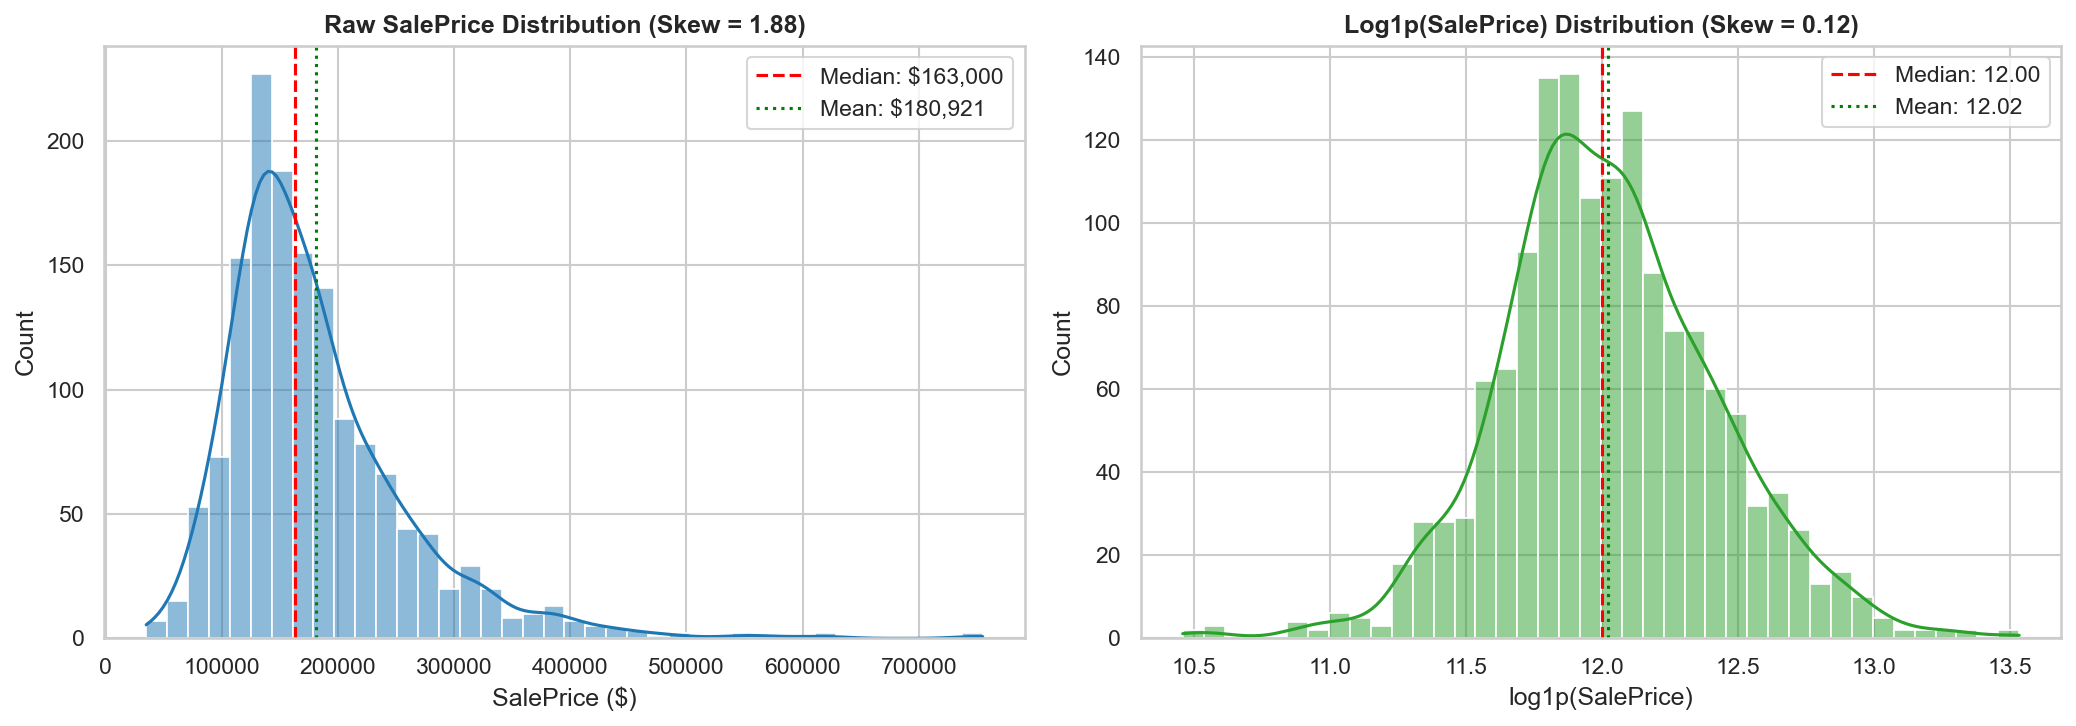

Raw SalePrice Skewness: 1.8829
Log1p(SalePrice) Skewness: 0.1213
SalePrice Mean: $180,921.20 | Median: $163,000.00


In [3]:
sp_skew = df['SalePrice'].skew()
log_sp = np.log1p(df['SalePrice'])
log_sp_skew = log_sp.skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw SalePrice distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#1f77b4', bins=40)
axes[0].set_title(f'Raw SalePrice Distribution (Skew = {sp_skew:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['SalePrice'].median(), color='red', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].axvline(df['SalePrice'].mean(), color='green', linestyle=':', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].legend()

# Log-transformed SalePrice distribution
sns.histplot(log_sp, kde=True, ax=axes[1], color='#2ca02c', bins=40)
axes[1].set_title(f'Log1p(SalePrice) Distribution (Skew = {log_sp_skew:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Count')
axes[1].axvline(log_sp.median(), color='red', linestyle='--', label=f'Median: {log_sp.median():.2f}')
axes[1].axvline(log_sp.mean(), color='green', linestyle=':', label=f'Mean: {log_sp.mean():.2f}')
axes[1].legend()

plt.tight_layout()
fig_path = FIG_DIR / '02_target_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Raw SalePrice Skewness: {sp_skew:.4f}")
print(f"Log1p(SalePrice) Skewness: {log_sp_skew:.4f}")
print(f"SalePrice Mean: ${df['SalePrice'].mean():,.2f} | Median: ${df['SalePrice'].median():,.2f}")

### Key Numbers — Target
- **Raw `SalePrice` Skewness**: **+1.8829** (substantially right-skewed, heavy tail with extreme luxury outliers).
- **Log1p(`SalePrice`) Skewness**: **+0.1213** (nearly symmetric Gaussian distribution).
- **Mean vs. Median**: Mean ($180,921) exceeds Median ($163,000) by nearly $18,000 due to right skew. Log-transformation is mandatory for linear models and reduces RMSLE penalty.

## 3. Missing Values Diagnostics
Table of missing counts and percentages, categorized by domain meaning (`absent` facility vs. `unknown` data).

,missing_count,missing_pct,na_meaning
PoolQC,1453,99.52,absent
MiscFeature,1406,96.30,absent
Alley,1369,93.77,absent
Fence,1179,80.75,absent
MasVnrType,872,59.73,absent
FireplaceQu,690,47.26,absent
LotFrontage,259,17.74,unknown
GarageType,81,5.55,absent
GarageYrBlt,81,5.55,absent
GarageFinish,81,5.55,absent


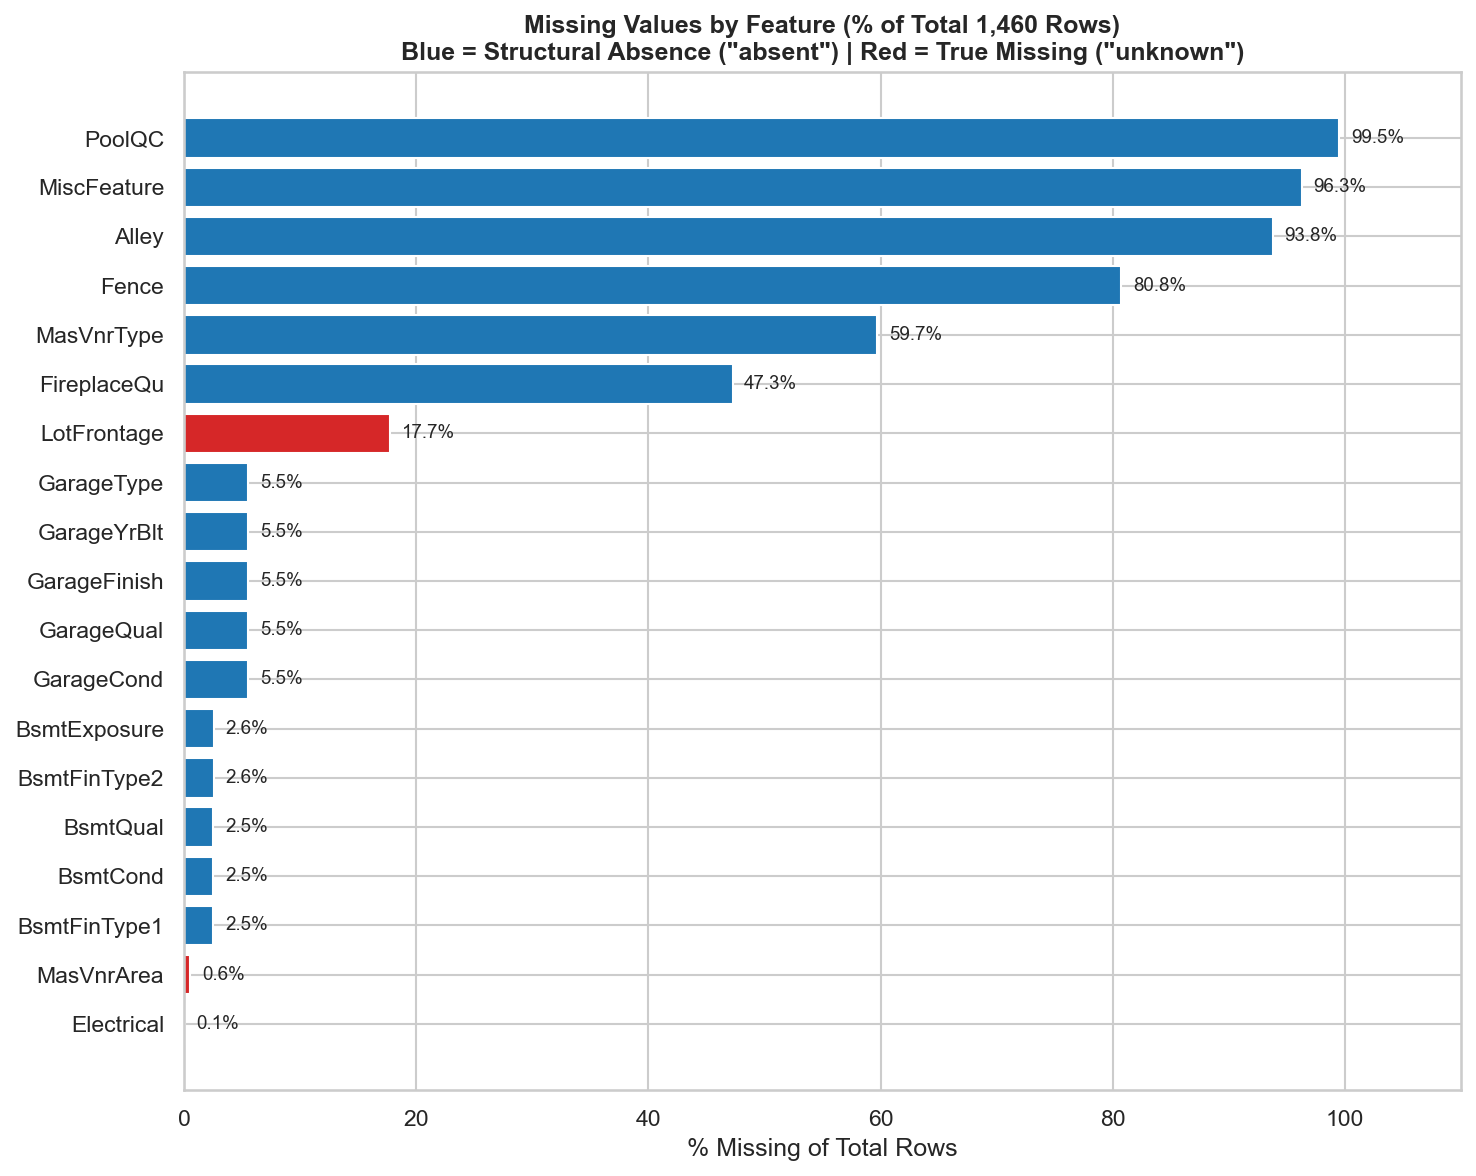

Total columns with missing values: 19
Structural 'absent' columns: 16
True 'unknown' columns: 3


In [4]:
missing_counts = df.isnull().sum()
missing_series = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_pct = (missing_series / len(df)) * 100

absent_patterns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'Garage', 'Bsmt', 'MasVnrType']

def classify_na(col):
    for pat in absent_patterns:
        if col.startswith(pat) or pat in col:
            return 'absent'
    return 'unknown'

missing_df = pd.DataFrame({
    'missing_count': missing_series,
    'missing_pct': missing_pct.round(2),
    'na_meaning': [classify_na(c) for c in missing_series.index]
})

display(missing_df)

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if meaning == 'unknown' else '#1f77b4' for meaning in missing_df['na_meaning']]
bars = ax.barh(missing_df.index[::-1], missing_df['missing_pct'][::-1], color=colors[::-1])
ax.set_xlabel('% Missing of Total Rows')
ax.set_title('Missing Values by Feature (% of Total 1,460 Rows)\nBlue = Structural Absence ("absent") | Red = True Missing ("unknown")', fontsize=12, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height() / 2, f'{width:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, 110)
plt.tight_layout()
fig_path = FIG_DIR / '03_missing_values.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Total columns with missing values: {len(missing_df)}")
print(f"Structural 'absent' columns: {(missing_df['na_meaning'] == 'absent').sum()}")
print(f"True 'unknown' columns: {(missing_df['na_meaning'] == 'unknown').sum()}")

### Key Numbers — Missing Values
- **Total Columns with Missing Values**: **19** columns out of 81.
- **Structural "Absent" Features (16 columns)**:
  - Extreme absence: `PoolQC` (99.52%, 1,453 missing), `MiscFeature` (96.30%, 1,406 missing), `Alley` (93.77%, 1,369 missing), `Fence` (80.75%, 1,179 missing).
  - Feature absence: `FireplaceQu` (47.26%, 690 missing), `MasVnrType` (59.73%, 872 missing).
  - Garage absence (81 missing, 5.55%): `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond`.
  - Basement absence (37–38 missing, 2.53%–2.60%): `BsmtExposure`, `BsmtFinType2`, `BsmtQual`, `BsmtCond`, `BsmtFinType1`.
- **True "Unknown" Features (3 columns)**:
  - `LotFrontage`: **259 missing (17.74%)** — requires median imputation grouped by Neighborhood.
  - `MasVnrArea`: **8 missing (0.55%)** — corresponds to missing masonry veneer.
  - `Electrical`: **1 missing (0.07%)** — single missing categorical record.

## 4. Outlier Diagnostics (GrLivArea vs. SalePrice)
Detecting extreme points with large living area (> 4,000 sq ft) and low sale price (< $300,000).

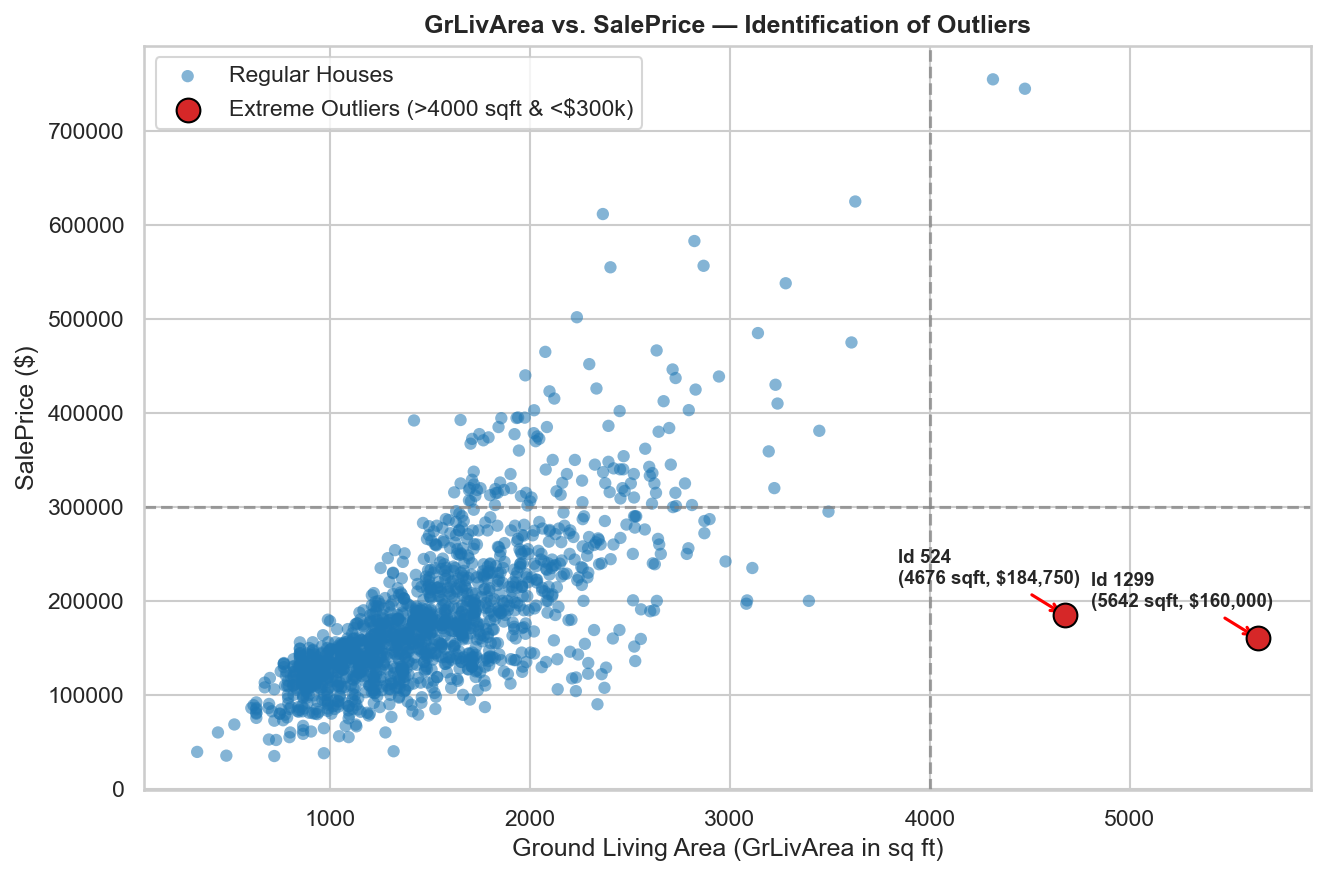

Number of extreme outliers identified: 2
Outlier details:
  Id  GrLivArea  SalePrice SaleCondition
 524       4676     184750       Partial
1299       5642     160000       Partial


In [5]:
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
normal_houses = df.drop(index=outliers.index)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(normal_houses['GrLivArea'], normal_houses['SalePrice'], alpha=0.55, color='#1f77b4', edgecolors='none', s=35, label='Regular Houses')
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='#d62728', s=130, edgecolors='black', zorder=5, label='Extreme Outliers (>4000 sqft & <$300k)')

# Reference thresholds
ax.axvline(4000, color='gray', linestyle='--', alpha=0.7)
ax.axhline(300000, color='gray', linestyle='--', alpha=0.7)

for _, row in outliers.iterrows():
    ax.annotate(f"Id {int(row['Id'])}\n({int(row['GrLivArea'])} sqft, ${int(row['SalePrice']):,})",
                (row['GrLivArea'], row['SalePrice']),
                textcoords="offset points", xytext=(-80, 15),
                fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle="->", color='red', lw=1.5))

ax.set_title('GrLivArea vs. SalePrice — Identification of Outliers', fontsize=12, fontweight='bold')
ax.set_xlabel('Ground Living Area (GrLivArea in sq ft)')
ax.set_ylabel('SalePrice ($)')
ax.legend(loc='upper left')
plt.tight_layout()
fig_path = FIG_DIR / '04_outliers_grlivarea_saleprice.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of extreme outliers identified: {len(outliers)}")
print("Outlier details:")
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'SaleCondition']].to_string(index=False))

### Key Numbers — Outliers
- **Extreme Outliers Identified**: Exactly **2 rows**:
  - **Id 524**: `GrLivArea` = 4,676 sq ft, `SalePrice` = $184,750, `SaleCondition` = Partial.
  - **Id 1299**: `GrLivArea` = 5,642 sq ft, `SalePrice` = $160,000, `SaleCondition` = Partial.
- Both properties are exceptionally large luxury houses sold as incomplete partial builds at deeply discounted prices. Per dataset documentation (Dean De Cock), these two observations distort model training and should be pruned.

## 5. Skewed Features
Identification of numeric features with absolute skewness exceeding 0.75.

In [6]:
num_features = df.select_dtypes(include=[np.number]).drop(columns=['Id'], errors='ignore')
feature_skews = num_features.skew().sort_values(key=abs, ascending=False)
skewed_df = pd.DataFrame({'Skewness': feature_skews, 'Abs_Skew': feature_skews.abs()})
skewed_table = skewed_df[skewed_df['Abs_Skew'] > 0.75].drop(columns=['Abs_Skew'])

print(f"Total numeric features evaluated (excluding Id): {len(num_features.columns)}")
print(f"Numeric features with |skew| > 0.75: {len(skewed_table)}")
display(skewed_table)

Total numeric features evaluated (excluding Id): 37
Numeric features with |skew| > 0.75: 22


,Skewness
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


### Key Numbers — Skewed Features
- **Total Numeric Features Evaluated**: 37 features (excluding `Id`).
- **Features with |skew| > 0.75**: **22 features** (21 feature predictors + target `SalePrice`).
- **Top 5 Most Severe Skews**:
  1. `MiscVal`: **+24.48**
  2. `PoolArea`: **+14.83**
  3. `LotArea`: **+12.21**
  4. `3SsnPorch`: **+10.30**
  5. `LowQualFinSF`: **+9.01**
- Features like `LotArea`, `GrLivArea`, `1stFlrSF`, and `TotalBsmtSF` will require power or log transformations.

## 6. Correlation & Multicollinearity Analysis
Top 15 numeric features correlated with `SalePrice`, correlation heatmap, and collinear pairs with $|r| > 0.85$.

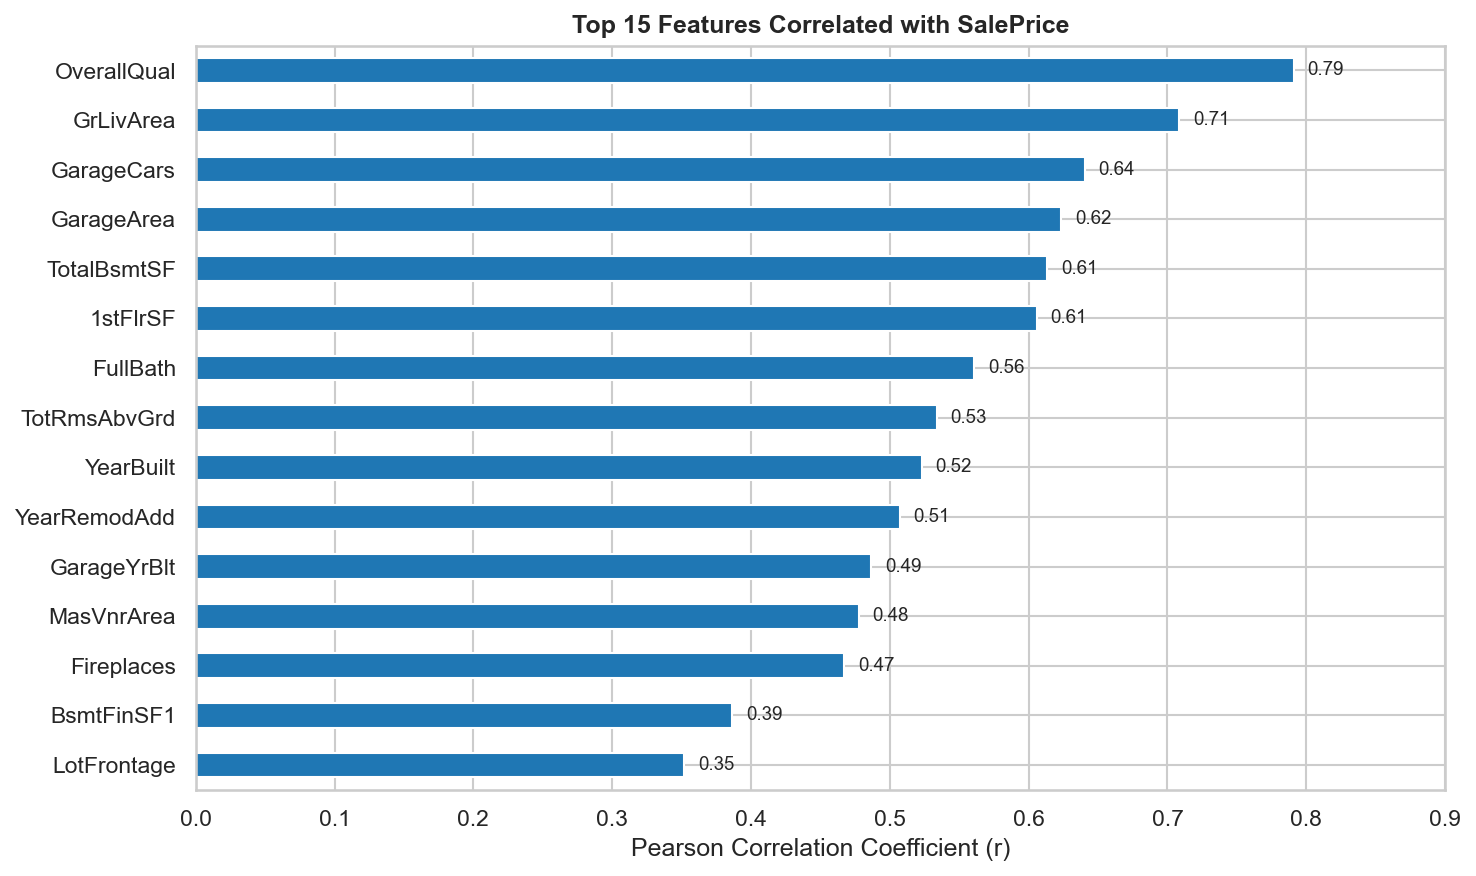

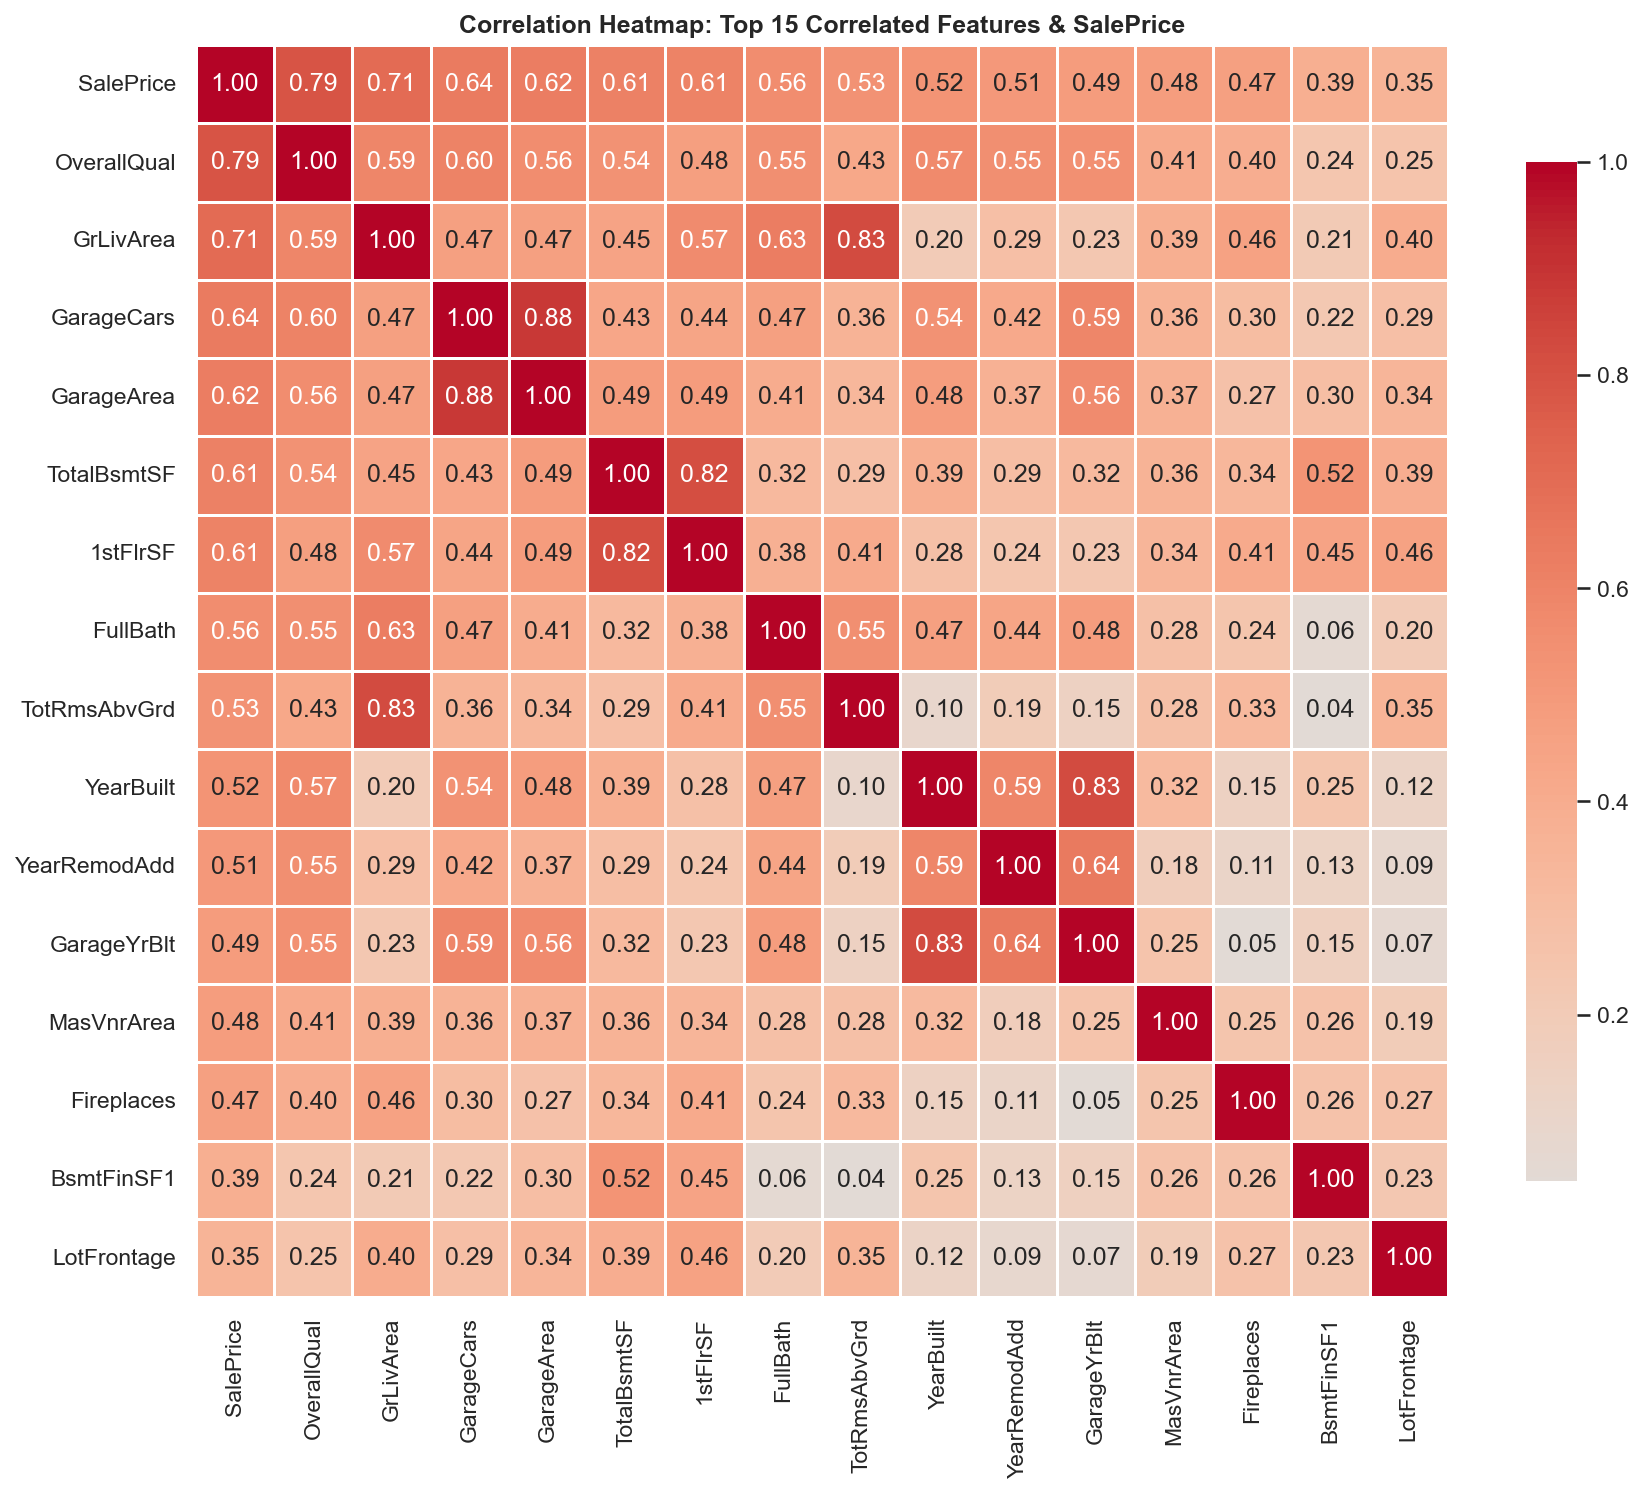

Feature pairs with high multicollinearity (|r| > 0.85):
  GarageCars <-> GarageArea: r = 0.8825


In [7]:
corr_matrix = num_features.corr()
target_corrs = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)
top15_features = target_corrs.head(15)

# Bar chart of Top 15 correlated features
fig, ax = plt.subplots(figsize=(10, 6))
top15_features.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('Top 15 Features Correlated with SalePrice', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient (r)')
for i, v in enumerate(top15_features.sort_values()):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlim(0, 0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_top15_correlations_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap of top 15 features + SalePrice
top15_cols = ['SalePrice'] + list(top15_features.index)
sub_corr = num_features[top15_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sub_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap: Top 15 Correlated Features & SalePrice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_top15_correlations_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Detect highly collinear feature pairs (|r| > 0.85)
collinear_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
        if f1 == 'SalePrice' or f2 == 'SalePrice':
            continue
        r_val = corr_matrix.iloc[i, j]
        if abs(r_val) > 0.85:
            collinear_pairs.append((f1, f2, r_val))

print("Feature pairs with high multicollinearity (|r| > 0.85):")
for f1, f2, r in collinear_pairs:
    print(f"  {f1} <-> {f2}: r = {r:.4f}")

### Key Numbers — Correlation
- **Top 5 Features Correlated with `SalePrice`**:
  1. `OverallQual`: **r = 0.7910**
  2. `GrLivArea`: **r = 0.7086**
  3. `GarageCars`: **r = 0.6404**
  4. `GarageArea`: **r = 0.6234**
  5. `TotalBsmtSF`: **r = 0.6136**
- **Collinear Feature Pairs ($|r| > 0.85$)**:
  - `GarageCars` $\leftrightarrow$ `GarageArea`: **r = 0.8825**
  - *(Notable runners-up: `GrLivArea` $\leftrightarrow$ `TotRmsAbvGrd`: r = 0.8255; `TotalBsmtSF` $\leftrightarrow$ `1stFlrSF`: r = 0.8195).*
  - Indicates redundant information between garage capacity and garage square footage.

## 7. Rare & Near-Constant Categories
Detecting categorical features with dominant values (> 95% share) and rare category levels (< 10 rows).

In [8]:
obj_cols = df.select_dtypes(include=['object']).columns

# Calculate share of the most frequent value
dominant_shares = {}
for col in obj_cols:
    counts = df[col].value_counts(normalize=True, dropna=False)
    dominant_shares[col] = {
        'dominant_val': str(counts.index[0]),
        'share_pct': round(counts.iloc[0] * 100, 2)
    }

dom_df = pd.DataFrame.from_dict(dominant_shares, orient='index').sort_values('share_pct', ascending=False)
near_constant_cols = dom_df[dom_df['share_pct'] > 95]
print("Categorical columns where most frequent value > 95%:")
display(near_constant_cols)

# List category levels with fewer than 10 rows
rare_levels_dict = {}
for col in obj_cols:
    counts = df[col].value_counts(dropna=True)
    rare = counts[counts < 10]
    if len(rare) > 0:
        for val, cnt in rare.items():
            rare_levels_dict[(col, val)] = cnt

rare_df = pd.DataFrame([
    {'column': col, 'level': val, 'count': cnt}
    for (col, val), cnt in rare_levels_dict.items()
]).sort_values(by=['column', 'count']).reset_index(drop=True)

print(f"Columns with near-constant values (>95%): {len(near_constant_cols)}")
print(f"Columns containing rare levels (<10 rows): {rare_df['column'].nunique()} out of {len(obj_cols)}")
print(f"Total rare levels (<10 rows) across dataset: {len(rare_df)}")
display(rare_df.head(20))

Categorical columns where most frequent value > 95%:


,dominant_val,share_pct
Utilities,AllPub,99.93
Street,Pave,99.59
PoolQC,nan,99.52
Condition2,Norm,98.97
RoofMatl,CompShg,98.22
Heating,GasA,97.81
MiscFeature,nan,96.30


Columns with near-constant values (>95%): 7
Columns containing rare levels (<10 rows): 25 out of 43
Total rare levels (<10 rows) across dataset: 68


,column,level,count
0,BsmtCond,Po,2
1,Condition1,RRNe,2
2,Condition1,RRNn,5
3,Condition1,PosA,8
4,Condition2,PosA,1
5,Condition2,RRAn,1
6,Condition2,RRAe,1
7,Condition2,Artery,2
8,Condition2,RRNn,2
9,Condition2,PosN,2


### Key Numbers — Rare / Near-Constant Categories
- **7 Near-Constant Columns (>95% single value)**:
  - `Utilities`: **99.93%** AllPub (only 1 single house has NoSeWa)
  - `Street`: **99.59%** Pave
  - `PoolQC`: **99.52%** NaN (no pool)
  - `Condition2`: **98.97%** Norm
  - `RoofMatl`: **98.22%** CompShg
  - `Heating`: **97.81%** GasA
  - `MiscFeature`: **96.30%** NaN (no misc feature)
- **Rare Levels**: **25** categorical columns contain a total of **68 rare levels** with fewer than 10 observations (e.g. `Electrical=Mix` [1 row], `Exterior1st=AsphShn` [1 row], `SaleType=Con` [2 rows]). These risk high CV fold variance and test set encoding mismatch.

## 8. Price Imbalance
Count of houses across price bands (< $150k, $150k–$300k, $300k–$450k, > $450k).

,Count,Percentage
PriceBand,,
<150k,615,42.12%
150-300k,730,50.00%
300-450k,101,6.92%
>450k,14,0.96%


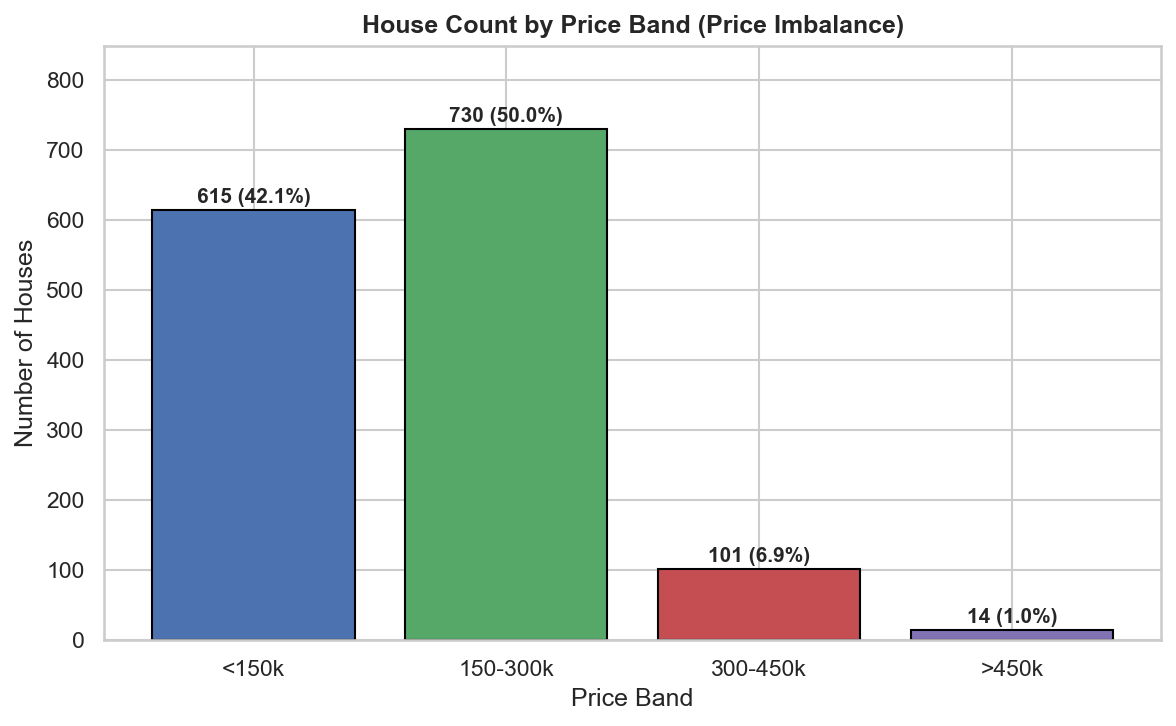

In [9]:
bins = [0, 150000, 300000, 450000, float('inf')]
labels = ['<150k', '150-300k', '300-450k', '>450k']
df['PriceBand'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, right=False)
band_counts = df['PriceBand'].value_counts()[labels]
band_pcts = (band_counts / len(df)) * 100

band_df = pd.DataFrame({
    'Count': band_counts,
    'Percentage': band_pcts.map('{:.2f}%'.format)
})
display(band_df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, band_counts, color=['#4c72b0', '#55a868', '#c44e52', '#8172b3'], edgecolor='black')
ax.set_title('House Count by Price Band (Price Imbalance)', fontsize=12, fontweight='bold')
ax.set_xlabel('Price Band')
ax.set_ylabel('Number of Houses')

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, y + 10, f'{int(y)} ({y/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 850)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_price_bands.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Numbers — Price Imbalance
- **< $150k**: **615 houses (42.12%)**
- **$150k - $300k**: **730 houses (50.00%)**
- **$300k - $450k**: **101 houses (6.92%)**
- **> $450k**: **14 houses (0.96%)**
- 92.12% of the entire housing stock falls below $300,000. Properties above $450k account for under 1% of the dataset, causing potential under-prediction on high-end homes.

## 9. Time Dynamics (YrSold)
Median SalePrice and transaction volume across sale years (2006–2010).

,count,median_price,mean_price
YrSold,,,
2006,314,163995.0,182549.458599
2007,329,167000.0,186063.151976
2008,304,164000.0,177360.838816
2009,338,162000.0,179432.103550
2010,175,155000.0,177393.674286


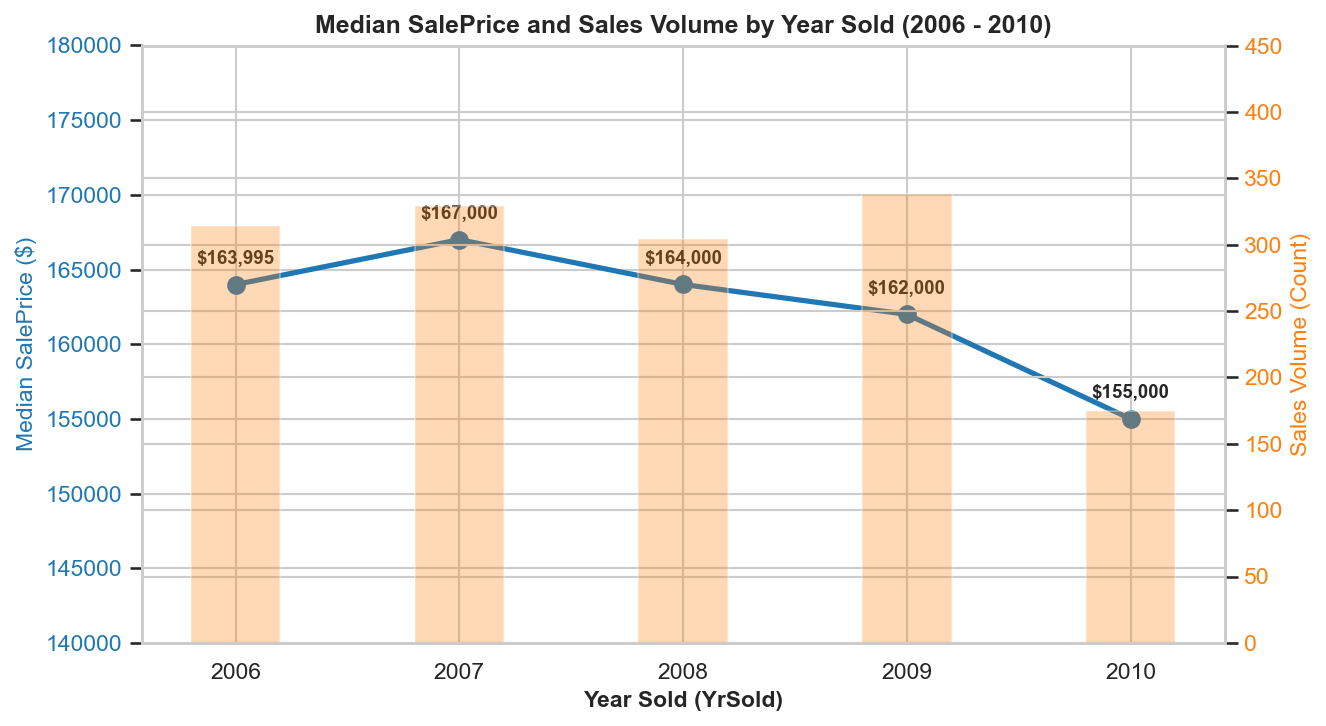

In [10]:
time_df = df.groupby('YrSold')['SalePrice'].agg(
    count='count',
    median_price='median',
    mean_price='mean'
)
display(time_df)

fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = '#1f77b4'
ax1.set_xlabel('Year Sold (YrSold)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Median SalePrice ($)', color=color1, fontsize=11)
line = ax1.plot(time_df.index, time_df['median_price'], color=color1, marker='o', linewidth=2.5, markersize=8, label='Median SalePrice')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(140000, 180000)
for x, y in zip(time_df.index, time_df['median_price']):
    ax1.annotate(f"${int(y):,}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.set_ylabel('Sales Volume (Count)', color=color2, fontsize=11)
bars = ax2.bar(time_df.index, time_df['count'], color=color2, alpha=0.3, width=0.4, label='Sales Count')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 450)

plt.title('Median SalePrice and Sales Volume by Year Sold (2006 - 2010)', fontsize=12, fontweight='bold')
ax1.set_xticks(time_df.index)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_price_and_volume_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Numbers — Time Trend
- **Yearly Breakdown**:
  - **2006**: 314 sales | Median = **$163,995**
  - **2007**: 329 sales | Median = **$167,000** (highest market prices)
  - **2008**: 304 sales | Median = **$164,000** (Great Financial Crisis onset)
  - **2009**: 338 sales | Median = **$162,000** (highest volume)
  - **2010**: 175 sales | Median = **$155,000** (market trough & partial year dataset)
- Transaction volume in 2010 dropped sharply to 175 because collection ended mid-year (July 2010).

## 10. Sale Condition Analysis
Transaction counts and median SalePrice grouped by `SaleCondition`.

,count,median_price,mean_price,share_pct
SaleCondition,,,,
Normal,1198,160000.0,175202.219533,82.05
Partial,125,244600.0,272291.752000,8.56
Abnorml,101,130000.0,146526.623762,6.92
Family,20,140500.0,149600.000000,1.37
Alloca,12,148145.0,167377.416667,0.82
AdjLand,4,104000.0,104125.000000,0.27


C:\Users\mshre\AppData\Local\Temp\ipykernel_22328\501492075.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cond_df.index, y=cond_df['count'], ax=axes[0], palette='Blues_r', edgecolor='black')


C:\Users\mshre\AppData\Local\Temp\ipykernel_22328\501492075.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cond_df.index, y=cond_df['median_price'], ax=axes[1], palette='Greens_r', edgecolor='black')


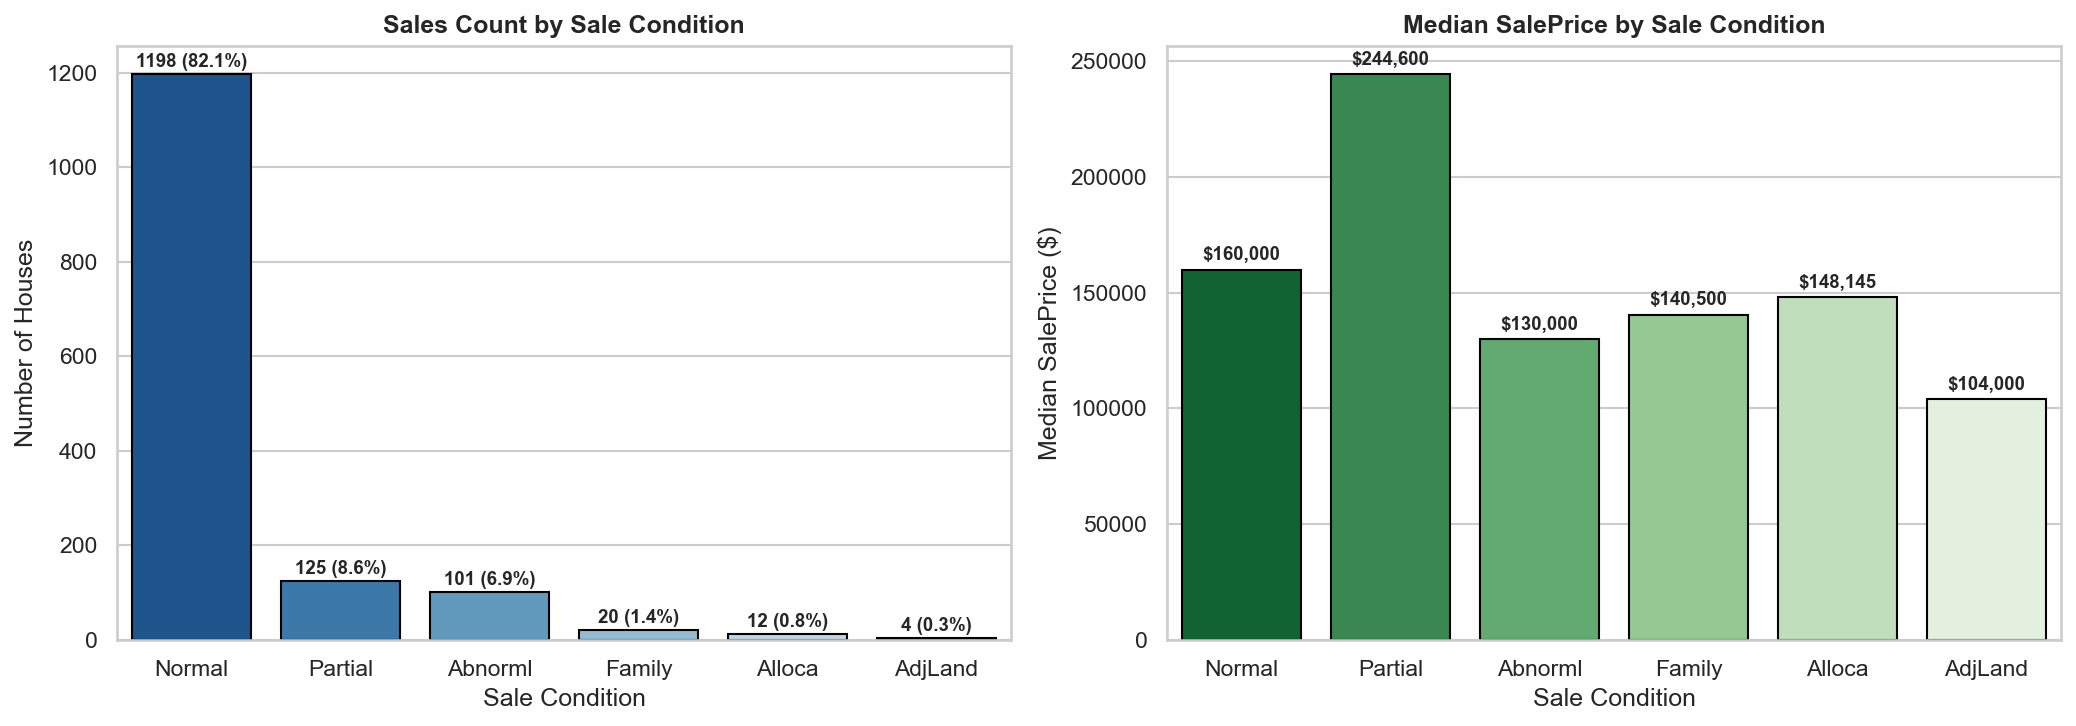

In [11]:
cond_df = df.groupby('SaleCondition')['SalePrice'].agg(
    count='count',
    median_price='median',
    mean_price='mean'
).sort_values('count', ascending=False)
cond_df['share_pct'] = (cond_df['count'] / len(df) * 100).round(2)
display(cond_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
sns.barplot(x=cond_df.index, y=cond_df['count'], ax=axes[0], palette='Blues_r', edgecolor='black')
axes[0].set_title('Sales Count by Sale Condition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Condition')
axes[0].set_ylabel('Number of Houses')
for i, v in enumerate(cond_df['count']):
    axes[0].text(i, v + 15, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# Median Price
sns.barplot(x=cond_df.index, y=cond_df['median_price'], ax=axes[1], palette='Greens_r', edgecolor='black')
axes[1].set_title('Median SalePrice by Sale Condition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sale Condition')
axes[1].set_ylabel('Median SalePrice ($)')
for i, v in enumerate(cond_df['median_price']):
    axes[1].text(i, v + 4000, f'${int(v):,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '10_sale_condition.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Numbers — Sale Condition
- **Normal**: **1,198 sales (82.05%)** | Median = **$160,000**
- **Partial**: **125 sales (8.56%)** | Median = **$244,600** (+52.88% premium over Normal; new constructions)
- **Abnorml**: **101 sales (6.92%)** | Median = **$130,000** (-18.75% discount; foreclosures/short sales)
- **Family**: **20 sales (1.37%)** | Median = **$140,500** (-12.19% discount)
- **Alloca**: **12 sales (0.82%)** | Median = **$148,145** (-7.41% discount)
- **AdjLand**: **4 sales (0.27%)** | Median = **$104,000** (-35.00% discount)

## 11. Location Analysis (Neighborhood)
Boxplot of `SalePrice` by `Neighborhood`, ordered by median price.

C:\Users\mshre\AppData\Local\Temp\ipykernel_22328\3501923596.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=neigh_order, ax=ax, palette='Spectral')


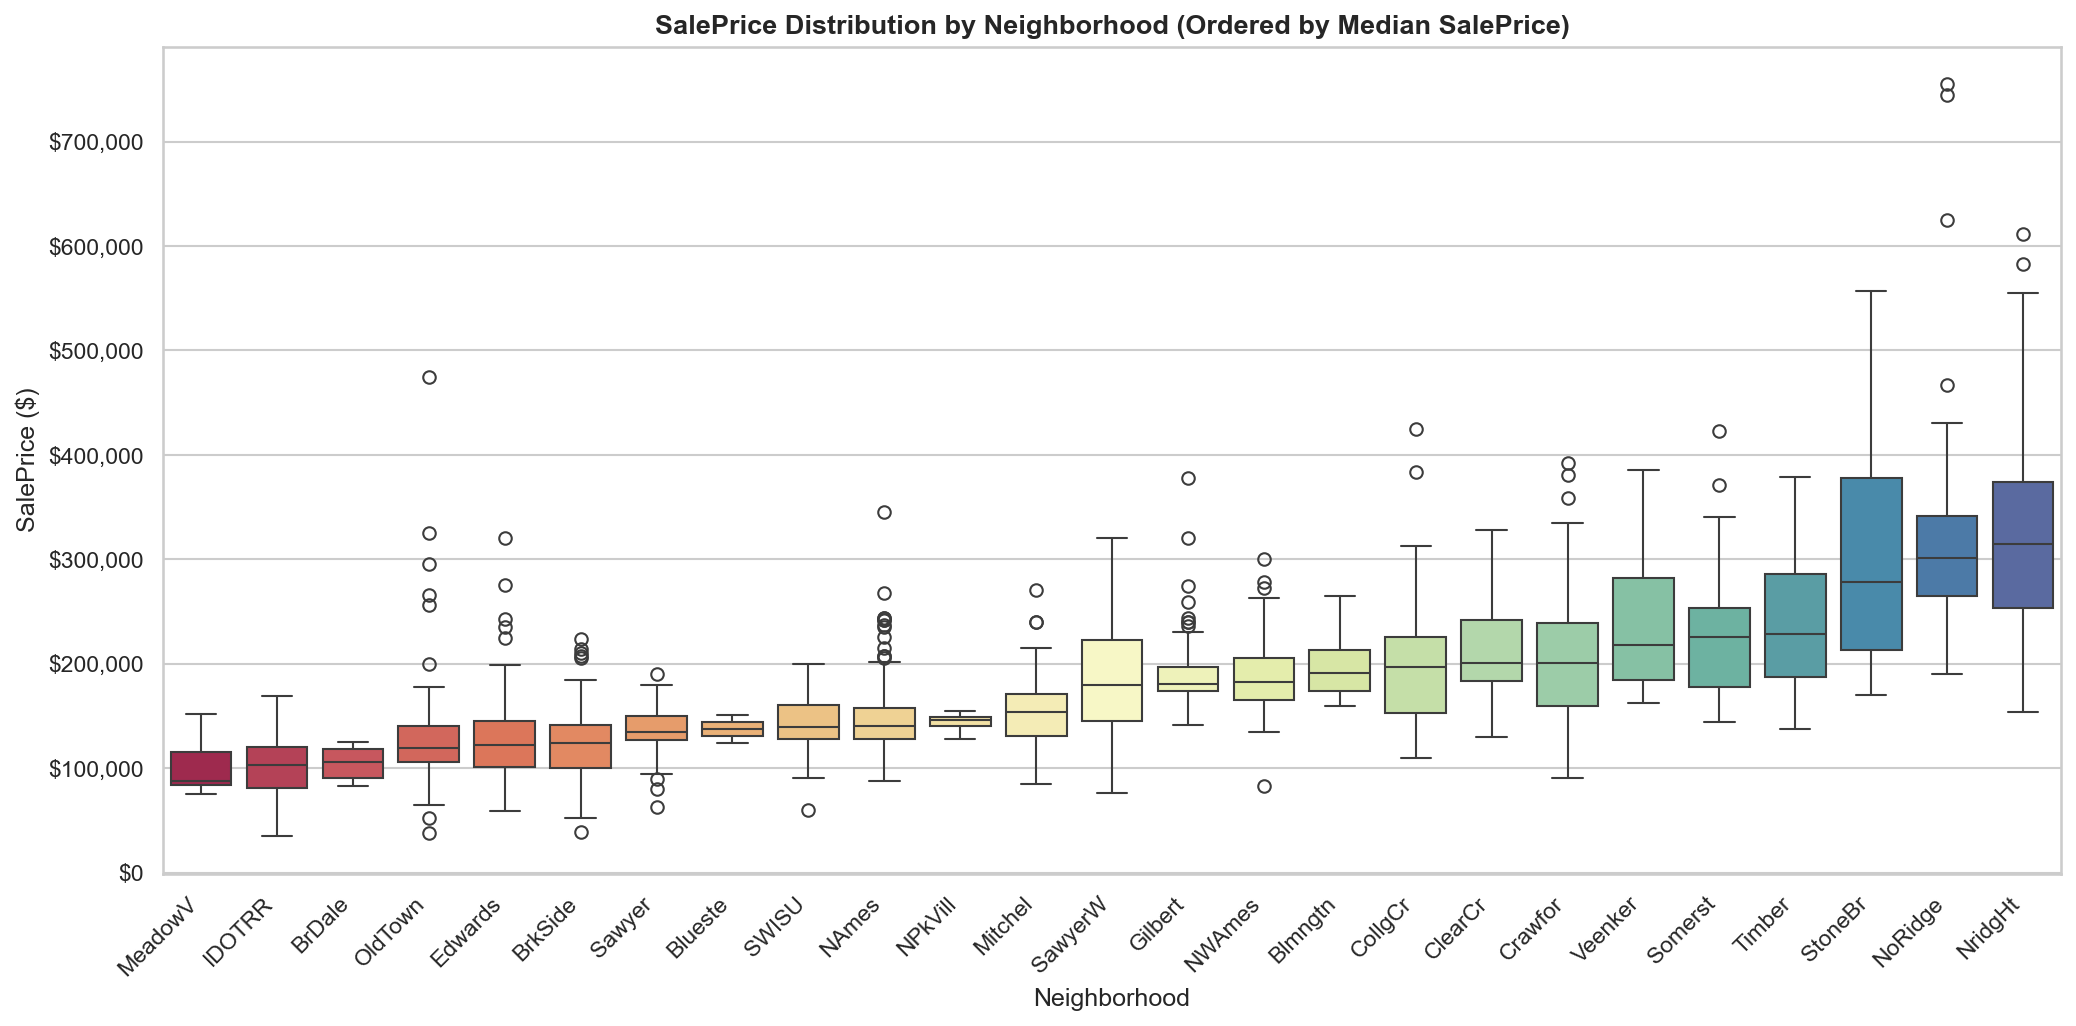

Top 3 Most Expensive Neighborhoods (by Median):


,count,median,min,max
Neighborhood,,,,
StoneBr,25,278000.0,170000,556581
NoRidge,41,301500.0,190000,755000
NridgHt,77,315000.0,154000,611657


Bottom 3 Most Affordable Neighborhoods (by Median):


,count,median,min,max
Neighborhood,,,,
MeadowV,17,88000.0,75000,151400
IDOTRR,37,103000.0,34900,169500
BrDale,16,106000.0,83000,125000


Price Ratio (Highest / Lowest Median): $315,000 / $88,000 = 3.58x


In [12]:
neigh_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=neigh_order, ax=ax, palette='Spectral')
plt.xticks(rotation=45, ha='right')
ax.set_title('SalePrice Distribution by Neighborhood (Ordered by Median SalePrice)', fontsize=13, fontweight='bold')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('SalePrice ($)')
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.savefig(FIG_DIR / '11_saleprice_by_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()

neigh_summary = df.groupby('Neighborhood')['SalePrice'].agg(
    count='count',
    median='median',
    min='min',
    max='max'
).loc[neigh_order]

print("Top 3 Most Expensive Neighborhoods (by Median):")
display(neigh_summary.tail(3))
print("Bottom 3 Most Affordable Neighborhoods (by Median):")
display(neigh_summary.head(3))

highest_med = neigh_summary['median'].max()
lowest_med = neigh_summary['median'].min()
print(f"Price Ratio (Highest / Lowest Median): ${highest_med:,.0f} / ${lowest_med:,.0f} = {highest_med/lowest_med:.2f}x")

### Key Numbers — Location
- **Total Neighborhoods**: **25** distinct neighborhoods in Ames, Iowa.
- **Top 3 Most Expensive (by Median)**:
  1. `NridgHt`: **$315,000** (Count: 77)
  2. `NoRidge`: **$301,500** (Count: 41)
  3. `StoneBr`: **$278,000** (Count: 25)
- **Bottom 3 Most Affordable (by Median)**:
  1. `MeadowV`: **$88,000** (Count: 17)
  2. `IDOTRR`: **$103,000** (Count: 38)
  3. `BrDale`: **$106,000** (Count: 16)
- **Geographic Disparity**: Median price in the most affluent neighborhood (`NridgHt`) is **3.58x** higher than the most affordable neighborhood (`MeadowV`).

## Problems found

A numbered summary of the data quality and modeling challenges diagnosed across sections 2–11:

1. **Target Skewness (Section 2)**: `SalePrice` is severely right-skewed with a skewness of **+1.8829** (mean $180,921 vs. median $163,000). Applying `np.log1p(SalePrice)` normalizes skewness to **+0.1213**, which is essential for minimizing relative error (RMSLE) and satisfying Gaussian assumptions.
2. **Missing Value Dual-Nature (Section 3)**: **19 columns** contain missing values. However, **16 columns** represent structural feature absence where NA indicates the facility does not exist (`PoolQC` 99.52%, `MiscFeature` 96.30%, `Alley` 93.77%, `Fence` 80.75%, `FireplaceQu` 47.26%, `MasVnrType` 59.73%, 5 `Garage*` features at 5.55%, and 5 `Bsmt*` features at 2.53%–2.60%). These require constant fill (`'None'` / `0`). Only **3 columns** represent true missing data (`LotFrontage` 17.74% [259 rows], `MasVnrArea` 0.55% [8 rows], `Electrical` 0.07% [1 row]) that require statistical imputation (e.g. median by neighborhood).
3. **Severe Outliers (Section 4)**: Exactly **2 observations** (`Id 524` with 4,676 sq ft sold for $184,750, and `Id 1299` with 5,642 sq ft sold for $160,000) have `GrLivArea > 4000` and `SalePrice < 300000`. Both were partial-build sales that severely distort ordinary least squares linear fits and should be dropped during preprocessing.
4. **Heavy Feature Skewness (Section 5)**: **22 numeric features** have $|\text{skew}| > 0.75$, led by `MiscVal` (+24.48), `PoolArea` (+14.83), `LotArea` (+12.21), `3SsnPorch` (+10.30), and `LowQualFinSF` (+9.01). Feature transformations (e.g., Box-Cox or Yeo-Johnson / log1p) are necessary to prevent high-leverage points.
5. **Multicollinearity (Section 6)**: `GarageCars` and `GarageArea` exhibit severe collinearity (**r = 0.8825**). Strong correlations also exist between `GrLivArea` and `TotRmsAbvGrd` (r = 0.8255), as well as `TotalBsmtSF` and `1stFlrSF` (r = 0.8195), causing variance inflation in unregularized linear models.
6. **Near-Constant / Zero-Variance Features (Section 7)**: **7 categorical columns** have a single dominant category exceeding **95% frequency**: `Utilities` (99.93% AllPub), `Street` (99.59% Pave), `PoolQC` (99.52% absent), `Condition2` (98.97% Norm), `RoofMatl` (98.22% CompShg), `Heating` (97.81% GasA), and `MiscFeature` (96.30% absent). These provide almost zero predictive variance.
7. **Rare Categorical Levels (Section 7)**: **25 categorical features** contain a total of **68 rare levels** with fewer than 10 rows (e.g., `RoofMatl=Membran` with only 1 instance). Such rare levels cause unstable coefficients and cross-validation folding issues, necessitating frequency grouping or target encoding.
8. **Target Price Imbalance (Section 8)**: **92.12%** of properties are concentrated below $300,000 (615 houses < $150k; 730 houses between $150k–$300k). Only **14 houses (0.96%)** are priced above $450,000, creating an under-representation of luxury homes that causes models to underpredict high-end properties.
9. **Truncated Time Window & Recession Dip (Section 9)**: Sales volumes remain steady from 2006–2009 (304–338 sales/yr) before collapsing to **175 sales in 2010** due to mid-year data collection truncation. Median prices peaked at **$167,000 in 2007** and dropped to **$155,000 in 2010**, capturing the impact of the 2008 subprime mortgage crisis.
10. **Sale Condition Valuation Distortions (Section 10)**: Non-normal sales introduce substantial pricing skews: `Partial` sales (8.56%) carry a **+52.88% median premium** ($244,600 vs. $160,000 Normal), while `Abnorml` sales (6.92%) trade at an **-18.75% discount** ($130,000) and `AdjLand` (0.27%) trades at a **-35.00% discount** ($104,000).
11. **Strong Geographic Price Disparity (Section 11)**: Across **25 neighborhoods**, median home prices range from **$88,000** in `MeadowV` to **$315,000** in `NridgHt`, a **3.58x price disparity**, confirming neighborhood location as one of the primary drivers of housing value.